![RMIT logo](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTlAppozhCGl50pjgEZu_tTmalWJi3TjpNwCg&s)
|Course|Foundations of Artificial Intelligence for STEM|
|-----|-------|
|Course Code|COSC2968/COSC3053|
|Lecturer(s)|Mr.Nhat-Quang Tran and Mrs.Anh Le Van|
|Full name - Student ID| Le Kim Quyen - s3983370<br>Ton Dat Toan - s4070286<br>Nguyen Hong Ha - s3979100<br>Huynh Bao Khoa Dang - s4045607<br>Nguyen Viet Ngan Anh - s4103086|

# Predicting the age of abalone

## Table of Contents
[1. Introduction](#intro) \
&emsp;[1.1. Overview](#intro_1) \
[2. Exploration Data Analysis (EDA)](#eda) \
&emsp;[2.1. Import Libraries and Modules](#eda_1) \
&emsp;[2.2. Load the dataset](#eda_2) \
&emsp;[2.3. Descriptive statistics, visualizations and correlation analysis](#eda_3) \
[3. Data Preprocessing](#data_preprocessing) \
&emsp;[3.1. Remove unused features](#data_preprocessing_1) \
&emsp;[3.2. Identify and handle outliers](#data_preprocessing_2) \
&emsp;[3.3. Split the data](#data_preprocessing_3) \
&emsp;[3.4. Separate labels from data](#data_preprocessing_4) \
&emsp;[3.5. Handle missing values](#data_preprocessing_5) \
&emsp;[3.6. Encode categorical features](#data_preprocessing_6) \
&emsp;[3.7. Scale numerical features](#data_preprocessing_7) \
[4. Model Training and Evaluation](#train_evaluate) \
&emsp;[4.1. Define support Functions](#train_evaluate_1) \
&emsp;&emsp;[4.1.1. R-squared (R2) and root mean squared error (RMSE) Function](#train_evaluate_1_1) \
&emsp;&emsp;[4.1.2. Function to store models](#train_evaluate_1_2) \
&emsp;[4.2. Training Models](#train_evaluate_2) \
&emsp;&emsp;[4.2.1. LinearRegression model](#train_evaluate_2_1) \
&emsp;&emsp;[4.2.2. DecisionTreeRegressor model](#train_evaluate_2_2) \
&emsp;&emsp;[4.2.3. RandomForestRegressor model](#train_evaluate_2_3) \
&emsp;&emsp;[4.2.4. ElasticNet model](#train_evaluate_2_4) \
&emsp;&emsp;[4.2.5. Gradient Boosting Regressor model](#train_evaluate_2_5) \
&emsp;&emsp;[4.2.6. Lasso model](#train_evaluate_2_6) \
&emsp;[4.3. Evaluate with K-fold cross validation](#train_evaluate_3) \
[5. Hyperparameter Fine-tuning](#hyperparameter) \
[6. Model Testing and Analysis](#test_anal) \
[7. References](#ref) \
[8. Contribution](#contribution)

## 1. Introduction <a class="anchor" id="intro"></a>

### 1.1. Overview <a id="intro_1"></a> 

&emsp;Abalones are not only a rich source of nutrition but also provide therapeutic benefits to various diseases such as asthma, atherosclerosis, and heart disease (Suleria et al., 2017). Therefore, it has become one of the most sought-after luxury dishes in some global markets, such as Chile, France, China, Japan, Korea and Vietnam. The high demand for this item has led to an upsurge in the number of abalone farms and fisheries over the past few decades. Because of a potentially abundant supply, reducing costs is essential to keep the products competitive in the market (Cook, 2023). Although the value of abalone and its age have a positive correlation, the old method to determine its age is still slow, expensive and inefficient. Traditionally, an abalone shell must be sliced through the cone, stained, and examined under a microscope to count the rings, each of which represents one year of the abalone. Some rings can be difficult to distinguish, so the estimated age is often multiplied by 1.5 (Akanda et al., 2023). Therefore, it is necessary to implement a new technology to streamline the age-determination process. 

&emsp;The goal of this research is to construct a regression model that estimates the age of abalone just from its physical characteristics, namely, Sex, Length, Diameter, Height, Whole height, Shucked height, Viscera height, and Shell height. This can help reduce the processing time and cost in abalone production. This report will consider six machine learning models, namely, linear regression model, decision tree regressor model, random forest regressor model, elastic net model, gradient boosting regressor, and lasso model, to find the optimal method. R-squared (R²) and Root Mean Squared Error (RMSE) are used to evaluate the models. 

*Write something here*

## 2. Exploration Data Analysis (EDA) <a class="anchor" id="eda"></a>

### 2.1. Import Libraries and Modules <a id="eda_1"></a>
Installing and getting started with Terminal (if necessary):
+ pip install matplotlib
+ pip install seaborn
+ pip install ydata-profiling
+ pip install ipywidgets
+ pip install scikit-learn

To install the necessary libraries / modules such as `pandas` [ref] for read dataset; `matplotlib` [ref], `seaborn` [ref] and `ydata` [ref] for visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

# run plots inline
%matplotlib inline

### 2.2. Load the dataset <a id="eda_2"></a>

In [ ]:
abalone_df = pd.read_csv('Documents/Datasets/abalone.csv')
abalone_df.head() # Shows the first five samples

&emsp;The dataset on abalone by Nash et al. (1995) was chosen due to several reasons. Firstly, in machine learning, particularly data analysis where datasets can range up to millions of samples, our chosen dataset is considered relatively moderate with a sample size of 4177, making it applicable in real-world scenarios. Secondly, there are eight different features, including one categorical feature, Type, and seven numeric features: Length, Diameter, Height, Whole height, Shucked height, Viscera height, and Shell height. The diversity in the number and dimensions makes the dataset satisfactory to the proposed regression models.

**Catagorical Feature:**
+ `Type`: Type of abalones (M = male, F = female and I = infant)

**Numerical Features:**
+ `Length`: Longest shell measurement in mm (continuous)
+ `Diameter`: Perpendicular to length in mm (continuous)
+ `Height`: with meat in shell in mm (continuous)
+ `Whole weight`: whole abalone in g (continuous)
+ `Shucked weight`: weight of meat in g (continuous)
+ `Viscera weight`: gut weight (after bleeding) in g (continuous)
+ `Shell weight`: after being dried in g (continuous)
+ `Rings`: +1.5 gives the age in years (discrete)

In [ ]:
abalone_df.info() # Shows overview of each feature

*Write something? Q - idk*

### 2.3. Descriptive statistics, visualizations and correlation analysis <a id="eda_3"></a>

**An overview using ydata** [ref]**:**

In [ ]:
# An overview using ydata
ydata = ProfileReport(abalone_df, title = 'Abalone overview')
ydata.to_notebook_iframe()
ydata.to_file('Documents/Figures/abalone.html')

*Write something? Q - idk*

**Scatter plot between every pair of feature using seaborn** [ref]**:**

In [ ]:
# An overview of the relationship between each pair feature
sns.set_theme() # set default theme for plot

# Plot features with each color for each type of abalone, including male (M), female (F) and infant (I)
sns.pairplot(data = abalone_df, hue = 'Type', corner = True, palette = 'Set2');

plt.savefig('Documents/Figures/pairplot.png') # save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**Compute correlations between features**

In [ ]:
# The variable contains correlations between features
abalone_corr = abalone_df.corr(numeric_only = True)

# uncomment to see data as table
# abalone_corr

**Visualize using headmap from seaborn** [ref]**:**

In [ ]:
ones_corr = np.ones_like(abalone_corr, dtype = bool) # create a matrix contains boolean values with the same shape as abalone_corr
mask = np.triu(ones_corr) # a mask contains half triangle matrix of True and False

# Remove redundant the first row and the last column
adjusted_abalone_corr = abalone_corr.iloc[1:, :-1]
adjusted_mask_corr = mask[1:, :-1]

# Create plot
fig, ax = plt.subplots(figsize = (10, 8))

# Show heatmap
sns.heatmap(data = adjusted_abalone_corr, mask = adjusted_mask_corr, cmap = 'Blues',
            annot = True, fmt = '.2f', vmin = -1, vmax = 1,
            linecolor = 'white', linewidths = .5, annot_kws = {'fontsize': 14});

plt.savefig('Documents/Figures/heatmap.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**Distribution of Numerical feature values**

In [ ]:
abalone_df.describe()

In [ ]:
abalone_df.hist(figsize=(10,15))
plt.savefig('Documents/Figures/histmap.png')
plt.show()

*Write something? Q - idk*

**Distribution of Categorical feature values**

In [ ]:
abalone_df.describe(include = 'object')

In [ ]:
sns.countplot(data = abalone_df, x = 'Type');

*Write something? Q - idk*

**The relationship between LongestShell and Rings using jointplot from seaborn** [ref]**:**

In [ ]:
sns.jointplot(data = abalone_df, x = 'LongestShell', y = 'Rings', hue = 'Type');

plt.savefig('Documents/Figures/longestshell_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between Diameter and Rings using FacetGrid from seaborn** [ref]**:**

In [ ]:
abalone_fg = sns.FacetGrid(data = abalone_df, col = 'Type')
abalone_fg.map(sns.scatterplot, 'Diameter', 'Rings', alpha = .4);

plt.savefig('Documents/Figures/diameter_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between Height and Rings using FaceGrid from seaborn** [ref]**:**

In [ ]:
abalone_fg = sns.FacetGrid(data = abalone_df, col = 'Type')
abalone_fg.map(sns.scatterplot, 'Height', 'Rings', alpha = .4);

plt.savefig('Documents/Figures/height_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

**The relationship between WholeWeight and Rings using jointplot from seaborn** [ref]**:**

In [ ]:
sns.jointplot(data = abalone_df, x = 'WholeWeight', y = 'Rings', hue = 'Type');

plt.savefig('Documents/Figures/wholeweight_rings.png') # Save as a picture in Figures folder
plt.show() # show plot

*Write something? Q - idk*

## 3. Data Preprocessing <a id="data_preprocessing"></a>

### 3.1. Remove unused features <a id="data_preprocessing_1"></a>

In [ ]:
abalone_df.drop(columns = ['ShuckedWeight', 'VisceraWeight', 'ShellWeight'], inplace = True)

# Uncomment to see the outcome
# abalone_df

*Write something? Q - idk*

### 3.2. Identify and handle outliers <a id="data_preprocessing_2"></a>
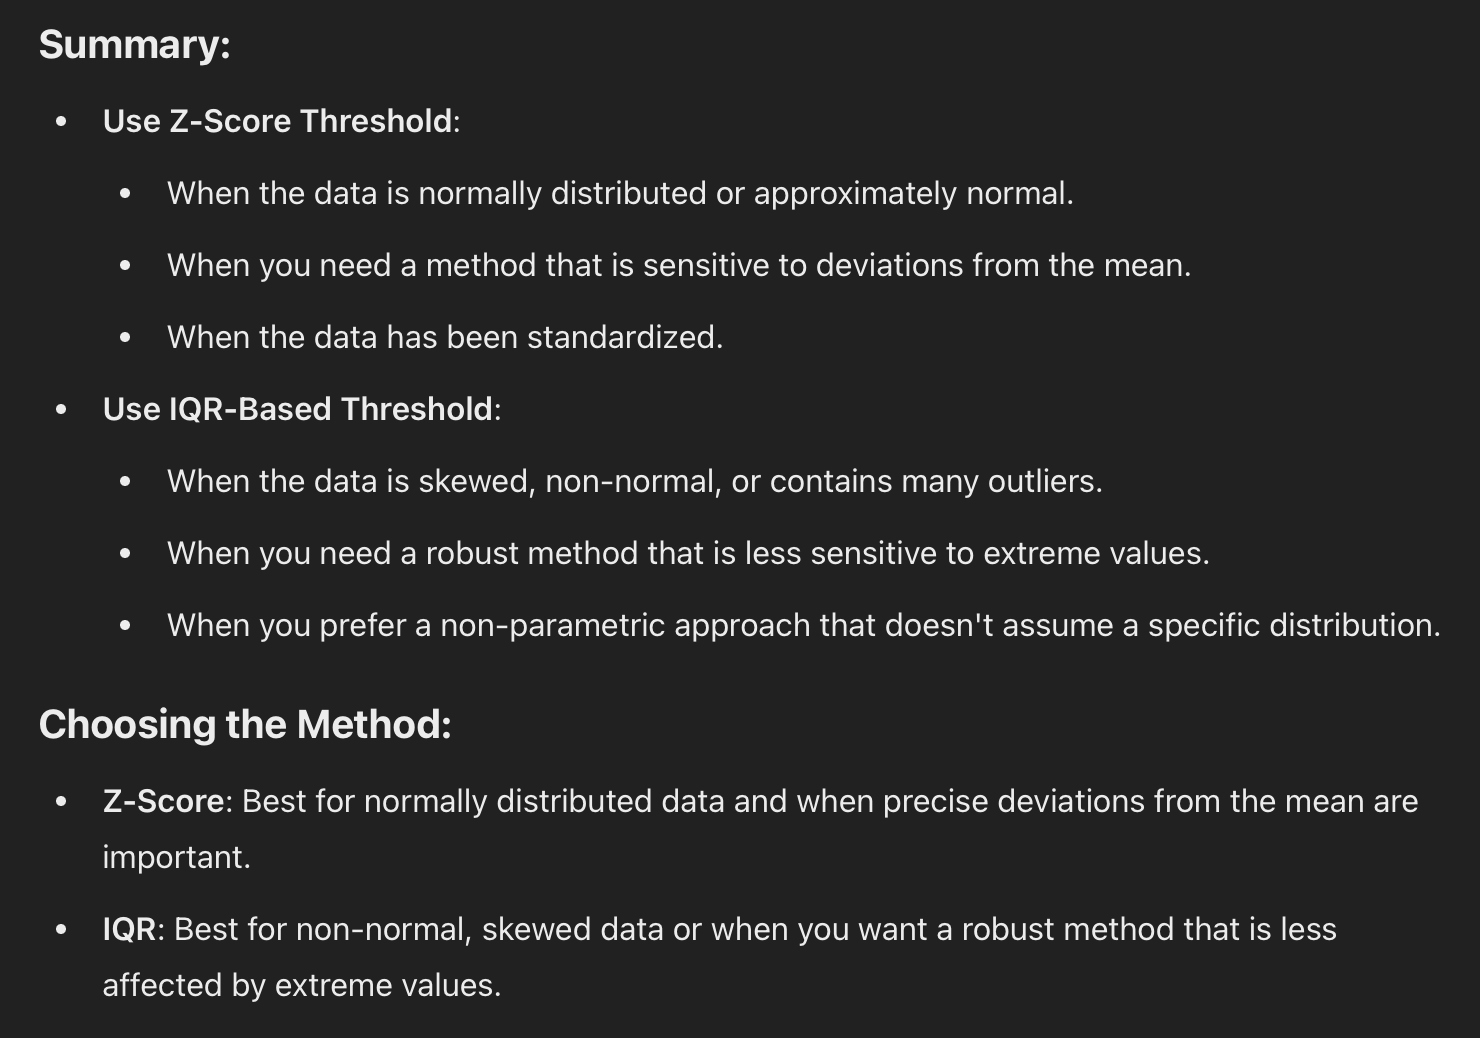 \
prompt chatGPT: "When to use Z-Score Threshold, when to use IQR-Based Threshold and how to use?"

In [ ]:
# Use Z-Score Threshold
for col in abalone_df.columns:
    if col != 'Type':
        # print(len(abalone_df[col]))
        threshold = 3
        mean_num = np.mean(abalone_df[col])
        std_num = np.std(abalone_df[col])

# on working

### 3.3. Split the data <a id="data_preprocessing_3"></a>

In [ ]:
from sklearn.model_selection import train_test_split

# Split the raw data: abalone_train (80%) for training and abalone_test (20%) for testing with the percentage
abalone_train, abalone_test = train_test_split(abalone_df, test_size = 0.2, random_state = 25)

# Uncomment to se the outcome
abalone_train.shape, abalone_test.shape

### 3.4. Separate labels from data <a id="data_preprocessing_4"></a>
Choosing "Rings" column as the label.

In [ ]:
# Split train set
train_set_labels = abalone_train['Rings'].copy()
train_set = abalone_train.drop(columns = 'Rings', inplace = False)

# Split test set
test_set_labels = abalone_test['Rings'].copy()
test_set = abalone_test.drop(columns = 'Rings', inplace = False)

*Write something? Q - idk*

### 3.5. Handle missing values <a id="data_preprocessing_5"></a>
There is no missing values to handle?? 😢 \
`mean`: The average value \
`median`: The mid point value \
link: https://www.w3schools.com/python/python_ml_mean_median_mode.asp

In [ ]:
from sklearn.impute import SimpleImputer

# Handle missing values in train_set and test_set
for i, set in enumerate([train_set, test_set]):
    if i == 0:
        print('____________ Training set ____________')
    else:
        print('____________ Testing set ____________')

    for col in set.columns:
        missing_values = set[col].isna().sum() # count number of missing values existed in a column
        if missing_values > 0:
            if col != 'Type': # find the nan values and replace by median number for numerical features
                imp_median = SimpleImputer(missing_values = np.nan, strategy = 'median')
                set[col] = imp_median.fit_transform(set[col].values.reshape(-1, 1))[:, 0]
            else: # find the nan values and replace by 'Unknown' string for categorical feature
                imp_type = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value = 'Unknown')
                set[col] = imp_type.fit_transform(set[col].values.reshape(-1, 1))[:, 0]
            
        print(f'Feature {col} has {missing_values / len(set) * 100}% missing values')
    print('')

# Handle missing value in labels
for i, label in enumerate([train_set_labels, test_set_labels]):
    if i == 0:
        set = 'training set'
    else:
        set = 'testing set'

    missing_values = label.isna().sum()
    if missing_values > 0:
        imp_median = SimpleImputer(missing_values = np.nan, strategy = 'median')
        label = imp_median.fit_transform(label.values.reshape(-1, 1))[:, 0]
    print(f'Label Rings in {set} has {missing_values / len(label) * 100}% missing values')

*Write something? Q - idk*

### 3.6. Encode categorical features <a id="data_preprocessing_6"></a>
There is one categorical feature in the dataset need to be encoded: `Type`

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create a class for encode columns
colTrans = ColumnTransformer(transformers = [('encode', OneHotEncoder(), [0])], remainder = 'passthrough')

# Encode
train_set = colTrans.fit_transform(train_set)
# train_set[0]
test_set = colTrans.transform(test_set)
# test_set[0]

In [ ]:
# Transform label column sets into the same format (array) with the above sets
train_set_labels = train_set_labels.values
test_set_labels = test_set_labels.values

### 3.7. Scale numerical features <a id="data_preprocessing_7"></a>
Scale features to zero mean and unit variance.

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

# Just only scale numerical features in training and testing set, not category feature
train_set[:, 3:] = std_scaler.fit_transform(train_set[:, 3:])
test_set[:, 3:] = std_scaler.transform(test_set[:, 3:])

## 4. Model Training and Evaluation <a id="train_evaluate"></a>

**Note:**
+ `train_set` contains set data for training
+ `train_set_labels` contains labels for training
+ `test_set` contains set data for testing
+ `test_set_labels` contains labels for testing

**Modules in lec:**
+ LinearRegression
+ DecisionTreeRegressor
+ RandomForestRegressor
+ PolynomialFeatures

### 4.1. Define support Functions <a id="train_evaluate_1"></a>

#### 4.1.1. R-squared (R2) and root mean squared error (RMSE) Function <a id="train_evaluate_1_1"></a>

In [ ]:
from sklearn.metrics import mean_squared_error

def r2score_and_rmse(model, train_data, labels): 
    r2score = model.score(train_data, labels)
    prediction = model.predict(train_data)
    mse = mean_squared_error(labels, prediction)
    rmse = np.sqrt(mse)
    return r2score, rmse

#### 4.1.2. Functions to store and load models <a id="train_evaluate_1_2"></a>
Parameters:
+ `action`: to distinguish between models training and models evaluation
+ `model`: model
+ `model_name`: name of model

In [ ]:
import joblib # new lib

def store_model(action, model, model_name = ''):
    # NOTE: sklearn.joblib faster than pickle of Python
    # INFO: can store only ONE object in a file
    if model_name == '': 
        model_name = type(model).__name__
    joblib.dump(model,f'Documents/Models/{model_name}_model_{action}.pkl')

def load_model(action, model_name):
    # Load objects into memory
    #del model
    model = joblib.load(f'Documents/Models/{model_name}_model_{action}.pkl')
    #print(model)
    return model

### 4.2. Training Models <a id="train_evaluate_2"></a>

#### 4.2.1. LinearRegression model <a id="train_evaluate_2_1"></a>

In [ ]:
from sklearn.linear_model import LinearRegression

# Create an empty model
model = LinearRegression()

# Call function to training model
model.fit(train_set, train_set_labels)
print('\n____________ LinearRegression ____________')

# Compute R2 score and root mean squared error
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')
        
# Predict labels for some training instances (9 first samples)
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)

*Write something? Q - idk*

#### 4.2.2. DecisionTreeRegressor model <a id="train_evaluate_2_2"></a>

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create an empty model
model = DecisionTreeRegressor()

# Training model
model.fit(train_set, train_set_labels)

# Compute R2 score and root mean squared error
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ DecisionTreeRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict labels for some training instances (the first 9 samples)
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)

*Write something? Q - idk*

#### 4.2.3. RandomForestRegressor model <a id="train_evaluate_2_3"></a>

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create an empty model
model = RandomForestRegressor()

# Training model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ RandomForestRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)

*Write something? Q - idk*

#### 4.2.4. ElasticNet model <a id="train_evaluate_2_4"></a>

In [ ]:
from sklearn.linear_model import ElasticNet

# Create Elastic net model
model = ElasticNet()

# Train the model 
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ ElasticNet ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


*Write something? Q - idk*

#### 4.2.5. Gradient Boosting Regressor <a id="train_evaluate_2_5"></a>
`n_estimators` : the number of boosting stages that will be performed. Later, we will plot deviance against boosting iterations.

`max_depth` : limits the number of nodes in the tree. The best value depends on the interaction of the input variables.

`min_samples_split` : the minimum number of samples required to split an internal node.

`learning_rate` : how much the contribution of each tree will shrink.

`loss` : loss function to optimize. The least squares function is used in this case however, there are many other options

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}
model = GradientBoostingRegressor(**params)

# Train the model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ GradientBoostingRegressor ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)


*Write something? Q - idk*

#### 4.2.6. Lasso model <a id="train_evaluate_2_6"></a>

In [ ]:
from sklearn.linear_model import Lasso

# Create the model
model = Lasso(alpha=0.1)

# Train the model
model.fit(train_set, train_set_labels)

# Compute R2 and RMSE
r2score, rmse = r2score_and_rmse(model, train_set, train_set_labels)

print('\n____________ Lasso ____________')
print(f'\nR2 score (on training data, best = 1): {r2score}')
print(f'Root Mean Square Error: {rmse.round(decimals = 1)}')

# Predict the first 9 samples
print('\nPredictions: ', model.predict(train_set[0:9]).round(decimals = 1))
print('Labels:      ', list(train_set_labels[0:9]))

# Store model
store_model('training', model)

*Write something? Q - idk*

### 4.3. Evaluate with K-fold cross validation <a id="train_evaluate_3"></a>
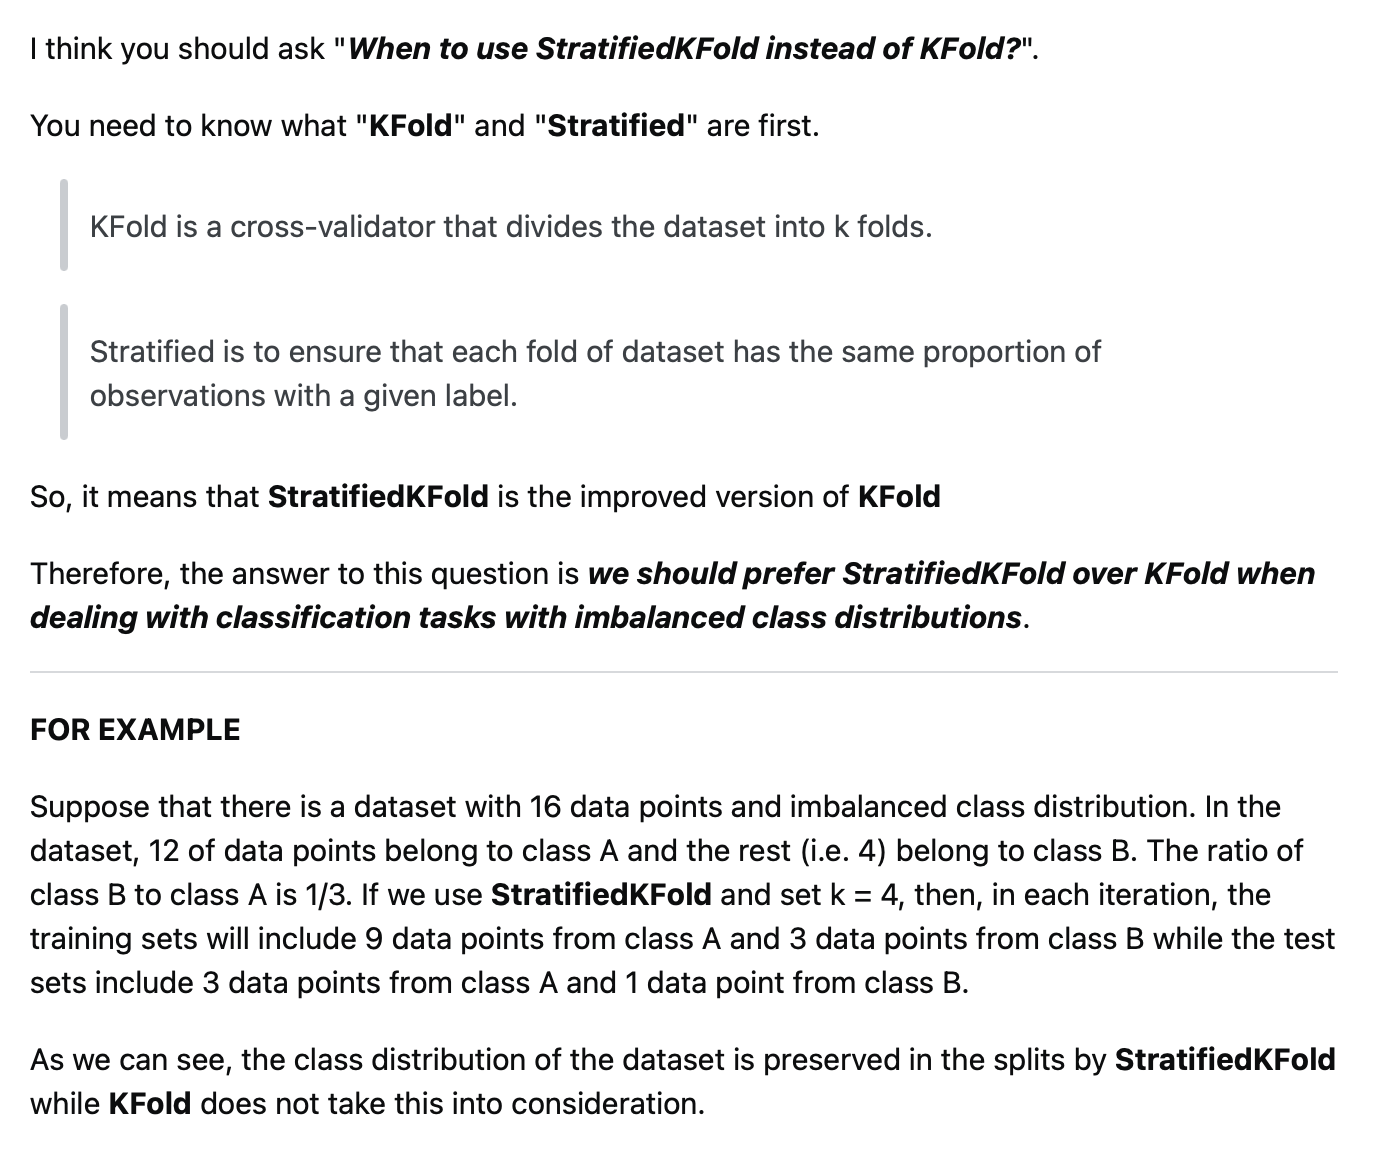 \
**Lec:** "KFold randomly splits data, hence does NOT ensure data splits are the same (only StratifiedKFold may ensure that)" \
=> The answer for using K-fold instead of StratifiedKFold for our training


I think the categorical feature (`Type`) is not much that *imbalanced* - Q


*Write something? Q - idk*

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from statistics import mean

cv = KFold(n_splits = 5, shuffle = True, random_state = 25)

# Evaluate LinearRegression
model = LinearRegression()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate DecisionTreeRegressor
model = DecisionTreeRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate RandomForestRegressor
model = RandomForestRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate ElasticNet model
model = ElasticNet()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate GradientBoostingRegressor
model = GradientBoostingRegressor()
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')


# Evaluate Lasso model
model = Lasso(alpha = .1)
model_name = model.__class__.__name__

nmse_scores = cross_val_score(model, train_set, train_set_labels, cv = cv, scoring = 'neg_mean_squared_error')
rmse_scores = np.sqrt(-nmse_scores)
store_model('evaluation', rmse_scores, model_name)
print(f'{model_name} rmse: {rmse_scores.round(decimals = 1)}')
print(f'Avg. rmse: {mean(rmse_scores.round(decimals = 5))}\n')

## 5. Hyperparameter Fine-tuning <a id="hyperparameter"></a>
"Random search is generally more efficient when the hyperparameter space is large and the optimal hyperparameters are not highly correlated, whereas grid search is more efficient when the hyperparameters are highly correlated and have a strong interaction effect." Link: https://360digitmg.com/blog/comparison-gridsearchcv-and-randomsearchcv#:~:text=Random%20search%20is%20generally%20more,have%20a%20strong%20interaction%20effect.

Now we will try to make the model more accurate, reduce the rmse score by tuning the parameters 

### 5.1. Support function <a id="hyperparameter_1"></a>
Function to print the output for fine-tune.

In [ ]:
def print_search_result(search, model_name = ""): 
    print("\n====== Fine-tune " + model_name +" ======")
    print('Best hyperparameter combination: ',search.best_params_)
    print('Best rmse: ', np.sqrt(-search.best_score_))  
    #print('Best estimator: ', grid_search.best_estimator_) # NOTE: require refit=True in  SearchCV
    # print('Performance of hyperparameter combinations:')
    # cv_results = search.cv_results_
    # for (mean_score, params) in zip(cv_results["mean_test_score"], cv_results["params"]):
    #     print('rmse =', np.sqrt(-mean_score), params) 

### 5.2. Grid serach <a id="hyperparameter_2"></a>

In [ ]:
method = 1 # Grid search
if method == 1:
    from sklearn.model_selection import GridSearchCV
    cv = KFold(n_splits=3,shuffle=True,random_state=25) # cv data generator
        
    run_new_search = 1      
    if run_new_search:        
        
        # 5.1.1 Fine-tune GradientBoostingRegressor, since it is the best model
        model = GradientBoostingRegressor()
        model_name = model.__class__.__name__
        param_grid = {
            # try combinations of parameters

            'n_estimators': [50, 100, 150],  # numbers of trees built
            # higher the more trees builts, improve performace but may lead to overfitting

            'learning_rate': [0.01, 0.05, 0.1],  # Shrinkage of the contribution of trees
            # how much a tree can contribute, lower mean each tree contribute less, but make the model more accurate, for the cost of learning time

            'max_depth': [1, 3, 5],  # max depth of each tree
            # max depth for each tree, can capture more complex pattern, but can lead to overfitting
            
            'min_samples_split': [2, 5, 10],   # min numbers of samples required to split an internal node
            # Higher value prevent spliting nodes, prevent overfitting

            'min_samples_leaf': [1, 2, 4], # min numbers of samples to be at a leaf node
            # Ensure each leaf has enough sample, preventing leaves with too few samples

            'subsample': [0.6, 0.7, 1.0], # split sample for fitting into tree
            # less mean more trees, improbing generalization, but requires more trees.
            'max_features': [0.2, 0.5, 0.7]  # numbers of features to consider when looking for the best split
            # Add randomness in the tree building process. Ex: 0.2 of total features, 1 is all features
            }
            # Train cross 5 folds, hence a total of (37500)*5=187500 rounds of training 
        grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=8, verbose=10, return_train_score=True, 
        refit=True) # refit=True: after finding best hyperparam, it fit() the model with whole data (hope to get better result)
        
        # Start fitting to find best model
        grid_search.fit(train_set, train_set_labels)
        store_model('grid_serach', grid_search, model_name)
        print_search_result(grid_search, model_name)

### 5.3 Randomized Search

## 6. Model Testing and Analysis <a id="test_anal"></a>

## 7. References <a id="ref"></a>

## 8. Contribution <a id="contribution"></a>
|Student ID|Student Name|Contribution Rate <br> (1-100%)|Responsible for <br> (Parts, Cells...)|Note|
|------|------|------|------|------|
|s3983370|Le Kim Quyen| | | |
|s4070286|Ton Dat Toan| | | |
|s3979100|Nguyen Hong Ha| | | |
|s4045607|Huynh Bao Khoa Dang| | | |
|s4103086|Nguyen Viet Ngan Anh| | | |